<a href="https://colab.research.google.com/github/Aymane-Aziz/toxic-comment-classifier/blob/main/00_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_c89dd025186b28f0e5d56b1995c086bc"
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [10]:
!kaggle competitions download -c jigsaw-toxic-comment-classification-challenge \
  -p /content/drive/MyDrive/toxic-comment-classifier/data

!unzip /content/drive/MyDrive/toxic-comment-classifier/data/jigsaw-toxic-comment-classification-challenge.zip \
  -d /content/drive/MyDrive/toxic-comment-classifier/data/

100% 52.6M/52.6M [00:00<00:00, 116MB/s]

Archive:  /content/drive/MyDrive/toxic-comment-classifier/data/jigsaw-toxic-comment-classification-challenge.zip
  inflating: /content/drive/MyDrive/toxic-comment-classifier/data/sample_submission.csv.zip  
  inflating: /content/drive/MyDrive/toxic-comment-classifier/data/test.csv.zip  
  inflating: /content/drive/MyDrive/toxic-comment-classifier/data/test_labels.csv.zip  
  inflating: /content/drive/MyDrive/toxic-comment-classifier/data/train.csv.zip  


In [14]:
%cd /content/drive/MyDrive/toxic-comment-classifier/data

/content/drive/MyDrive/toxic-comment-classifier/data


In [15]:
!ls

jigsaw-toxic-comment-classification-challenge.zip  test_labels.csv.zip
sample_submission.csv.zip			   train.csv.zip
test.csv.zip


In [17]:
!unzip -o "*.zip"

Archive:  jigsaw-toxic-comment-classification-challenge.zip
  inflating: sample_submission.csv.zip  
  inflating: test.csv.zip            
  inflating: test_labels.csv.zip     
  inflating: train.csv.zip           

Archive:  sample_submission.csv.zip
  inflating: sample_submission.csv   

Archive:  test.csv.zip
  inflating: test.csv                

Archive:  test_labels.csv.zip
  inflating: test_labels.csv         

Archive:  train.csv.zip
  inflating: train.csv               

5 archives were successfully processed.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
BASE_PATH = '/content/drive/MyDrive/toxic-comment-classifier/data/'

df = pd.read_csv(BASE_PATH + 'train.csv')
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [20]:
print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Dataset shape: (159571, 8)

Column names: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Data types:
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


/tmp/ipykernel_284/1378634306.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')


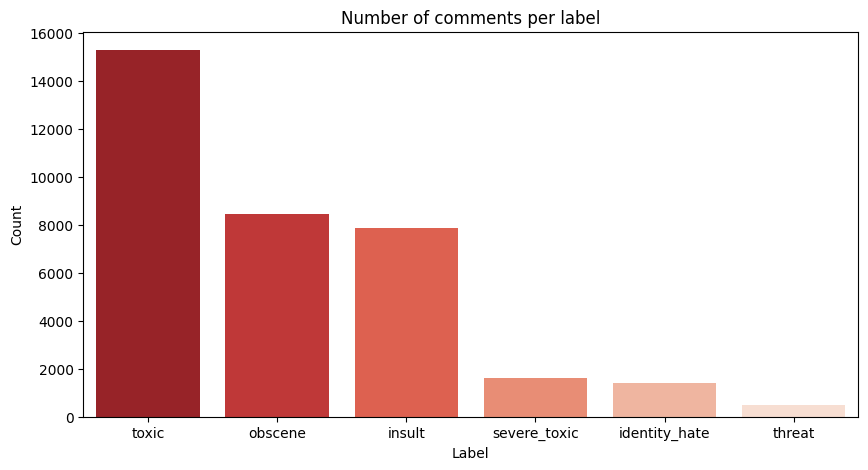


Label percentages:
toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30
dtype: float64


In [21]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

label_counts = df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Reds_r')
plt.title('Number of comments per label')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

# Percentage of each label
print("\nLabel percentages:")
print((label_counts / len(df) * 100).round(2))

/tmp/ipykernel_284/1628485644.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Clean', 'Toxic'], y=[clean, toxic], palette=['steelblue', 'tomato'])


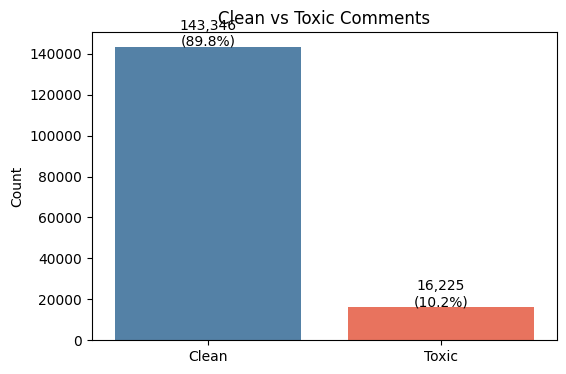

In [22]:
# How many comments have at least one toxic label?
df['is_toxic'] = df[label_cols].max(axis=1)

clean = (df['is_toxic'] == 0).sum()
toxic = (df['is_toxic'] == 1).sum()

plt.figure(figsize=(6, 4))
sns.barplot(x=['Clean', 'Toxic'], y=[clean, toxic], palette=['steelblue', 'tomato'])
plt.title('Clean vs Toxic Comments')
plt.ylabel('Count')
for i, v in enumerate([clean, toxic]):
    plt.text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')
plt.show()

Label count distribution:
label_count
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64


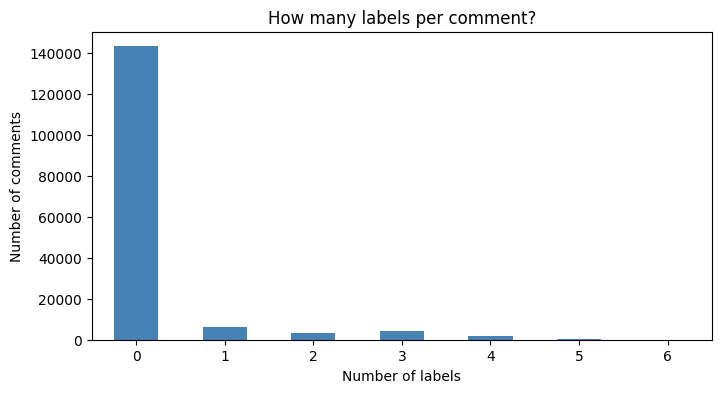

In [23]:
# How many comments have multiple labels at once?
df['label_count'] = df[label_cols].sum(axis=1)

print("Label count distribution:")
print(df['label_count'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['label_count'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('How many labels per comment?')
plt.xlabel('Number of labels')
plt.ylabel('Number of comments')
plt.xticks(rotation=0)
plt.show()

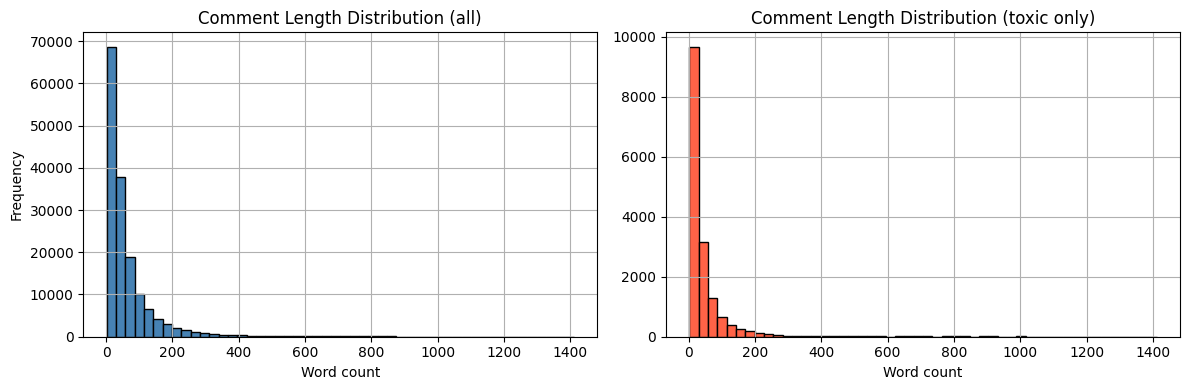

Average length — All: 67 words
Average length — Toxic: 53 words
Max length: 1411 words
% of comments over 128 tokens: 12.7%


In [24]:
df['text_length'] = df['comment_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['text_length'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Comment Length Distribution (all)')
plt.xlabel('Word count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df[df['is_toxic'] == 1]['text_length'].hist(bins=50, color='tomato', edgecolor='black')
plt.title('Comment Length Distribution (toxic only)')
plt.xlabel('Word count')

plt.tight_layout()
plt.show()

print(f"Average length — All: {df['text_length'].mean():.0f} words")
print(f"Average length — Toxic: {df[df['is_toxic']==1]['text_length'].mean():.0f} words")
print(f"Max length: {df['text_length'].max()} words")
print(f"% of comments over 128 tokens: {(df['text_length'] > 128).mean()*100:.1f}%")


## EDA Key Findings

1. Dataset has 159,571 comments with 6 binary labels
2. Dataset is heavily imbalanced — only X% of comments are toxic
3. Most frequent label: toxic (X%), least frequent: threat (X%)
4. Labels are correlated — obscene and toxic co-occur frequently
5. Average comment length is ~X words; X% exceed 128 tokens
6. Text contains URLs, special characters and formatting noise → needs cleaning
7. Strategy for imbalance: use weighted loss during training
